In [ ]:
#  HW4 CS-3753-01T-202530

#Open the Google Colab file link in the pdf, exercises.ipynb. Open the file while signed in to a google account.
#Run the code by clicking the run button by each question code.
#If there are issues with the Colab, download and run the program in Jupyter Notebook and run it in the correct location.

##%% import necessary modules
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
from sklearn import linear_model
import pdb #for debugging the code. Set a breakpoint by pbd.set_trace(). https://www.geeksforgeeks.org/python-debugger-python-pdb/

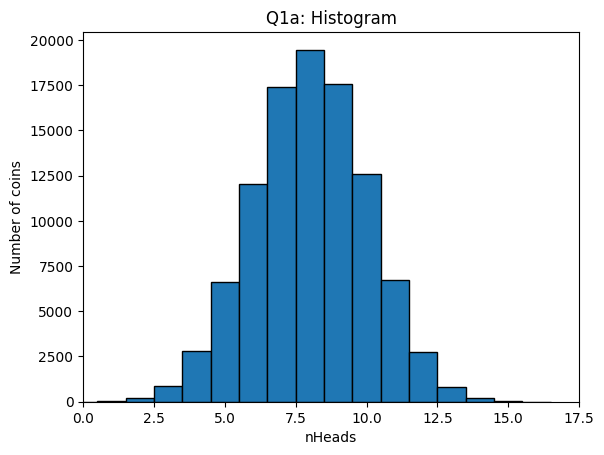

In [ ]:
##%% Q1 Statistics, 60pts
import scipy.stats as stats
import numpy.random as rn
##%% Q1a, 15pts
rn.seed(0)
N = 16
m = 10**5

#for coin throwing
nHeads = (rn.uniform(size=(m, N)) > 0.5).sum(1)

##%% plot the histogram
plt.hist(nHeads, bins=np.arange(-0.5, N+1.5, 1), edgecolor='black')
plt.xlabel('nHeads')
plt.ylabel('Number of coins')
plt.title('Q1a: Histogram')
plt.xlim([0.0, 17.5])
plt.xticks(np.arange(0.0, 18.0, 2.5))
plt.show()




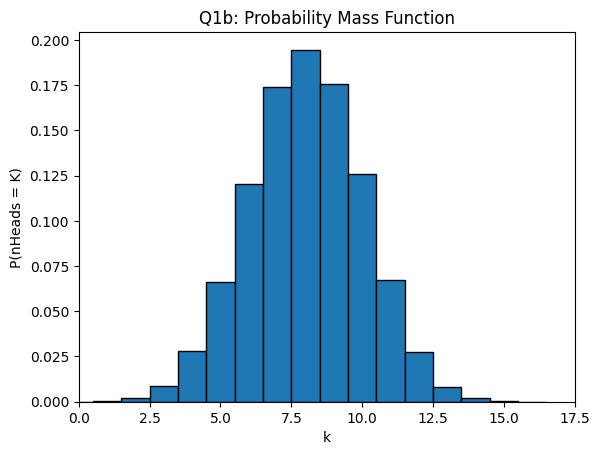

In [ ]:
##%% Q1b, 10pts
# using plt.hist with parameter bins and density
#Your code is here

plt.hist(nHeads, bins=np.arange(-0.5, N + 1.5, 1), density=True, edgecolor='black')
plt.xlabel('k')
plt.ylabel('P(nHeads = K)')
plt.title('Q1b: Probability Mass Function')
plt.xlim([0.0, 17.5])
plt.xticks(np.arange(0.0, 18.0, 2.5))
plt.show()



In [ ]:
##%% Q1c, 15pts

#Use the values of counts returned from a or b.
#Use the function cumsum to get the CDF.
# Do not use scipy.stats.binom

counts, bins = np.histogram(nHeads, bins=np.arange(-0.5, N + 1.5, 1), density=True)

cdf = np.cumsum(counts)

k_values = np.arange(0, N + 1)
plt.plot(k_values, cdf)
plt.xlabel('k')
plt.ylabel('P(nHeads <= k)')
plt.title('Q1c: Cumulative Distribution Function')
plt.grid(True)
plt.xlim([0, 16])
plt.ylim([0, 1.05])
plt.show()


In [ ]:
##%% Q1d, 20pts
# Use the binomial distribution CDF (use scipy.stats.binom.cdf)

# k val
k_values = np.arange(0, N + 1)

# Theoretical CDF: binomial distribution
theoretical_cdf = stats.binom.cdf(k_values, n=N, p=0.5)

# Empirical CDF
counts, _ = np.histogram(nHeads, bins=np.arange(-0.5, N + 1.5, 1), density=True)
empirical_cdf = np.cumsum(counts)

# scatter plot
plt.scatter(empirical_cdf, theoretical_cdf)
plt.xlabel('Empirical CDF')
plt.ylabel('Theoretical CDF')
plt.title('Q1d: Scatter plot ')
plt.grid(True)

plt.show()


# line colors
plt.plot(k_values, empirical_cdf, label='Empirical CDF', color='blue')
plt.plot(k_values, theoretical_cdf, label='Theoretical CDF', color='black')
plt.scatter(k_values, theoretical_cdf, color='orange')

plt.xlabel('k')
plt.ylabel('CDF')
plt.title('Q1d: line plot')
plt.legend()
plt.grid(True)
plt.xlim([0, 16])
plt.ylim([0, 1.05])
plt.show()

#loglog
plt.loglog(empirical_cdf, theoretical_cdf, marker='o', linestyle='None', color='blue')

plt.xlim(1e-5, 1)
plt.ylim(1e-5, 1)
plt.xlabel('Empirical CDF')
plt.ylabel('Theoretical CDF')
plt.title('Q1d: loglog plot')
plt.show()



In [ ]:

##%% Q2 Linear regression, 40pts

##%% Q2 i, 20pts
x = np.array([0.5, 2, 3])
y = np.array([1, 2.5, 3])

# printers/makers
models = {
    "a. y = x + 0.5": lambda x: x + 0.5,
    "b. y = x + 1": lambda x: x + 1,
    "c. y = 0.8x + 0.3": lambda x: 0.8 * x + 0.3,
    "d. y = 0.8x + 0.7": lambda x: 0.8 * x + 0.7,
}

# fidns and prints SSEs
sse_results = {}
for label, model in models.items():
    y_hat = model(x)
    residuals = y - y_hat
    sse = np.sum(residuals ** 2)
    sse_results[label] = sse
    print(f"{label}")
    print(f"prediction y: {y_hat}")
    print(f"residuals (y - y^): {residuals}")
    print(f"SSE: {sse:.4f}\n")

# smallest SSE calculator
best_model = min(sse_results, key=sse_results.get)
print(f"Lowest SSE model: {best_model} with SSE = {sse_results[best_model]:.4f}")



In [ ]:
##%% Q2 ii.a, 15pts
# the plot is not required

x = np.array([2005, 2006, 2007, 2008, 2009])
y = np.array([12, 19, 29, 37, 45])

#means
x_mean = np.mean(x)
y_mean = np.mean(y)

#for slope
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean)**2)
beta = numerator / denominator

# for intercept/alpha
alpha = y_mean - beta * x_mean

# regression line printing
print("Q2 ii (a): Least Squares Regression Line")
print(f"x mean (years): {x_mean}")
print(f"y mean (sales): {y_mean}")
print(f"Beta numerator: {numerator}")
print(f"Beta denominator: {denominator}")
print(f"Slope: {beta:.4f}")
print(f"Intercept: {alpha:.4f}")
print(f"Regression line: y = {beta:.4f}x + {alpha:.4f}")



In [ ]:
##%% Q2 ii.b, 5pts
x_2012 = 2012
estimated_sales_2012 = beta * x_2012 + alpha

print('Estimated sales in 2012 is', round(estimated_sales_2012, 2), 'million dollars')
#Output the result by print('Estimated sales in 2012 is ', XXX)